--- ORIGINAL BGR MATRIX (3x3 Sample) ---
[[[54 67 61]
  [54 67 61]
  [54 67 61]]

 [[54 67 61]
  [54 67 61]
  [54 67 61]]

 [[51 64 58]
  [51 64 58]
  [51 64 58]]]

--- GRAYSCALE MATRIX (3x3 Sample) ---
[[64 64 64]
 [64 64 64]
 [61 61 61]]


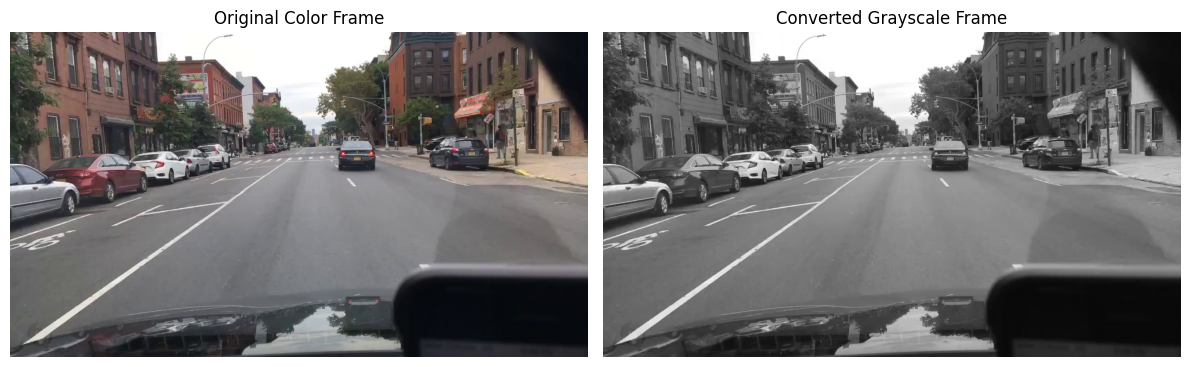

In [14]:
import cv2
import matplotlib.pyplot as plt

# 1. Load video and extract 1 frame
cap = cv2.VideoCapture('/content/026c7465-309f6d33.mp4')
ret, frame = cap.read()

if ret:
    # 2. Convert to Grayscale
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # 3. PRINT NUMERIC MATRICES (Top-Left 3x3 section for comparison)
    # Original is 3D (BGR), Grayscale is 2D (Single Intensity)
    print("--- ORIGINAL BGR MATRIX (3x3 Sample) ---")
    print(frame[0:3, 0:3])

    print("\n--- GRAYSCALE MATRIX (3x3 Sample) ---")
    print(gray_frame[0:3, 0:3])

    # 4. PRINT/VISUALISE BOTH IMAGES SIDE-BY-SIDE
    plt.figure(figsize=(12, 6))

    # Left: Original Color (Convert BGR to RGB for Matplotlib)
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.title("Original Color Frame")
    plt.axis('off')

    # Right: Grayscale
    plt.subplot(1, 2, 2)
    plt.imshow(gray_frame, cmap='gray')
    plt.title("Converted Grayscale Frame")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

else:
    print("Error: Video frame could not be extracted.")

cap.release()


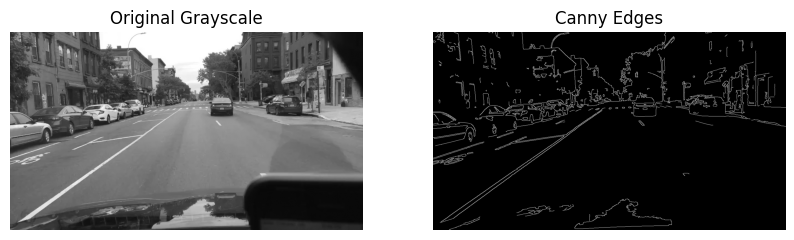

In [15]:
import cv2
import matplotlib.pyplot as plt

# 1. Load the video and extract the first frame
cap = cv2.VideoCapture('/content/026c7465-309f6d33.mp4')
ret, frame = cap.read()

if ret:
    # 2. Convert to Grayscale (Pre-processing)
    # Edge detection works best on single-channel intensity images
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # 3. Apply Gaussian Blur
    # Highly recommended to reduce noise before detecting edges
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # 4. Apply Canny Edge Detection
    # threshold1 (100): Lower bound for hysteresis thresholding
    # threshold2 (200): Upper bound for hysteresis thresholding
    edges = cv2.Canny(blurred, 100, 200)

    # 5. Display the Results
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.title("Original Grayscale")
    plt.imshow(gray, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Canny Edges")
    plt.imshow(edges, cmap='gray')
    plt.axis('off')

    plt.show()
else:
    print("Error: Could not extract frame.")

cap.release()


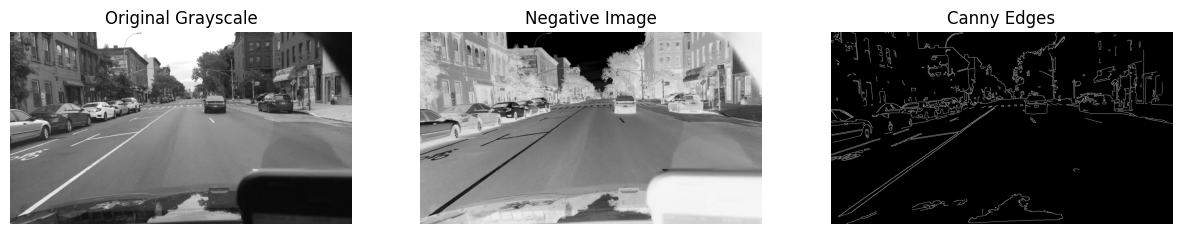

In [22]:
import cv2
import matplotlib.pyplot as plt

# 1. Load the video and extract the first frame
cap = cv2.VideoCapture('/content/026c7465-309f6d33.mp4')
ret, frame = cap.read()

if ret:
    # 2. Convert to Grayscale
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # 3. FIND THE NEGATIVE
    # Option A: Using OpenCV bitwise function
    negative = cv2.bitwise_not(gray)

    # Option B: Using simple math (255 - gray)
    # negative = 255 - gray

    # 4. Apply Canny Edge Detection (on the gray frame)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blurred, 100, 200)

    # 5. Display the Results (Including Negative)
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.title("Original Grayscale")
    plt.imshow(gray, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title("Negative Image")
    plt.imshow(negative, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title("Canny Edges")
    plt.imshow(edges, cmap='gray')
    plt.axis('off')

    plt.show()
else:
    print("Error: Could not extract frame.")

cap.release()


In [26]:
import cv2

# Method 1: The mathematical way
negative_img = 255 - original_img

# Method 2: The optimized OpenCV way
negative_img = cv2.bitwise_not(original_img)


NameError: name 'original_img' is not defined

--- ORIGINAL GRAYSCALE PIXELS ---
[[64 64 64 64 64]
 [64 64 64 64 64]
 [61 61 61 61 61]
 [60 60 60 60 60]
 [59 59 58 58 57]]

--- NEGATIVE IMAGE PIXELS (255 - Original) ---
[[191 191 191 191 191]
 [191 191 191 191 191]
 [194 194 194 194 194]
 [195 195 195 195 195]
 [196 196 197 197 198]]

--- Visual: Original vs Negative ---


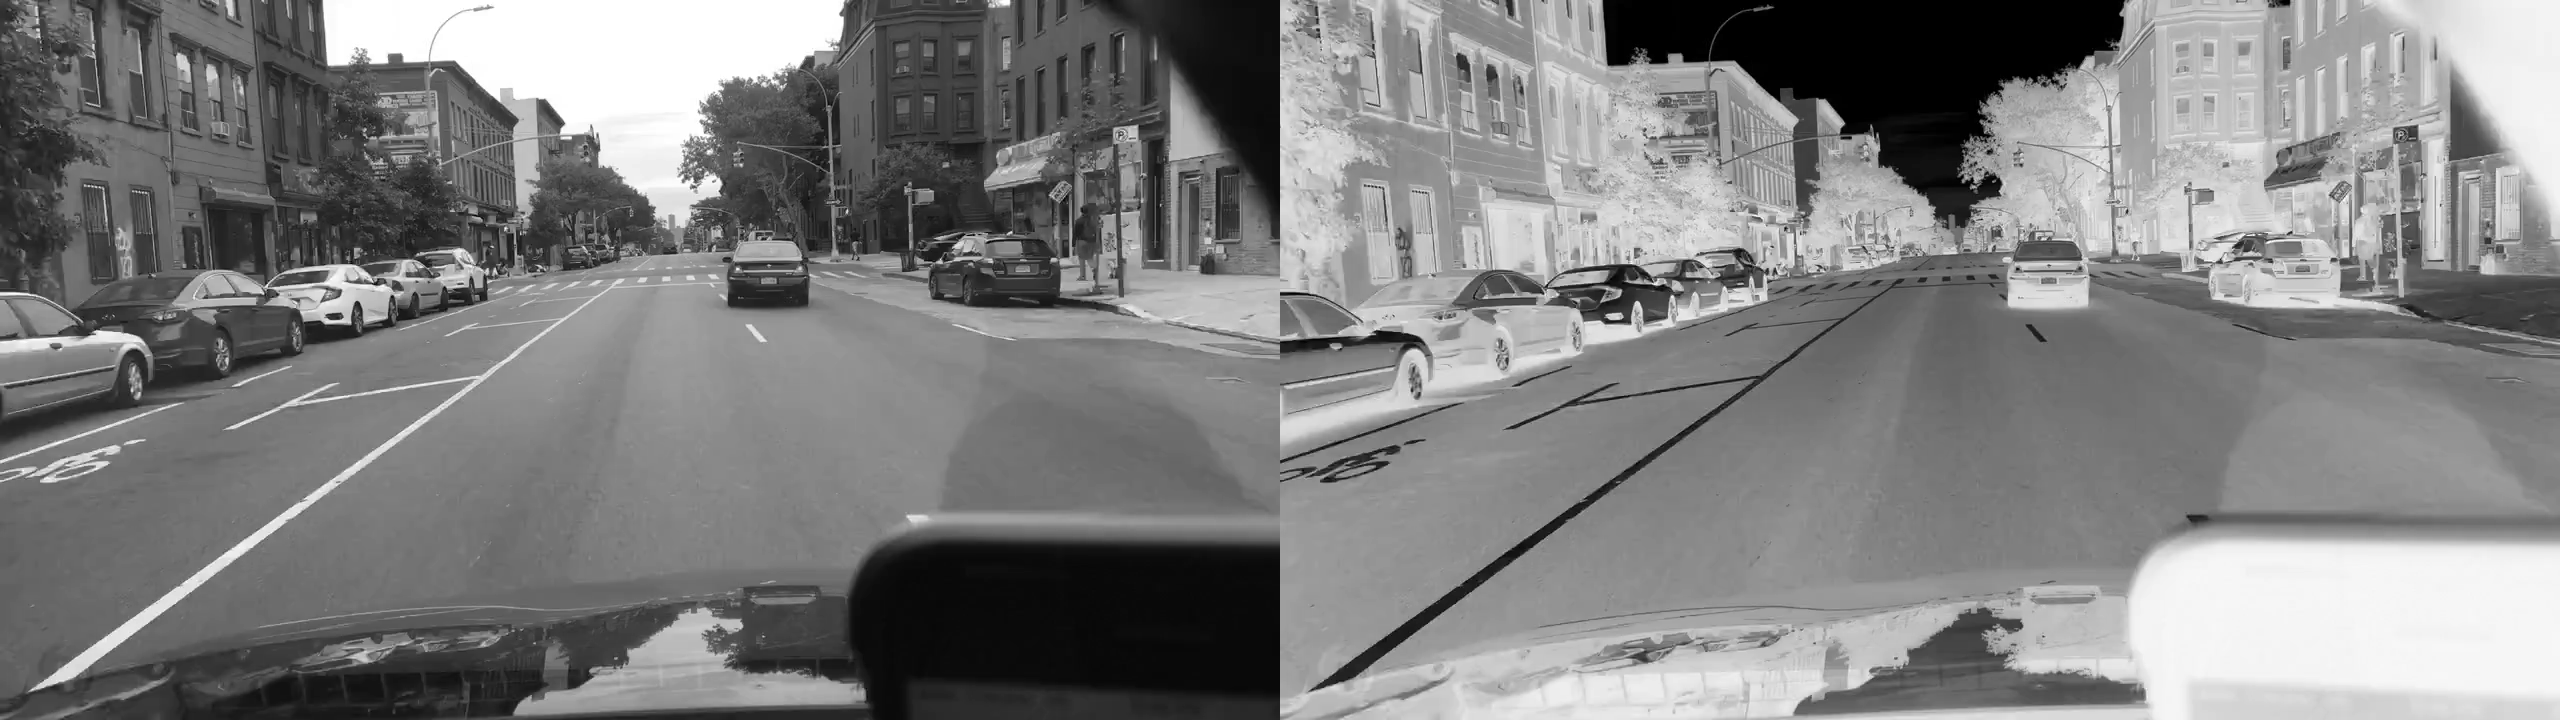

In [27]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# 1. Load the video
video_path = '/content/026c7465-309f6d33.mp4'
cap = cv2.VideoCapture(video_path)
ret, frame = cap.read()

if ret:
    # 2. Convert to Grayscale first (optional, but clearer for matrices)
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # 3. CALCULATE THE NEGATIVE
    # Math: Negative = 255 - Original
    # We use cv2.bitwise_not for the fastest performance
    negative_img = cv2.bitwise_not(gray)

    # 4. PRINT PIXEL MATRICES (Top-Left 5x5 area)
    print("--- ORIGINAL GRAYSCALE PIXELS ---")
    print(gray[0:5, 0:5])

    print("\n--- NEGATIVE IMAGE PIXELS (255 - Original) ---")
    print(negative_img[0:5, 0:5])

    # 5. DISPLAY VISUAL RESULTS
    print("\n--- Visual: Original vs Negative ---")
    # Stack images side-by-side to compare
    comparison = np.hstack((gray, negative_img))
    cv2_imshow(comparison)

else:
    print("Error: Could not extract frame from video.")

cap.release()
